In [1]:
from pathlib import Path
import numpy as np
import suite2p
import mbo_utilities as mbo
import lbm_suite2p_python as lsp
import lbm_suite2p_python.zplane

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),NVIDIA RTX A4000,DiscreteGPU,Vulkan,560.94
✅,NVIDIA RTX A4000,DiscreteGPU,D3D12,
✅,NVIDIA RTX A4000,DiscreteGPU,D3D12,
❗ limited,Microsoft Basic Render Driver,CPU,D3D12,
❌,NVIDIA RTX A4000/PCIe/SSE2,Unknown,OpenGL,4.6.0 NVIDIA 560.94


In [2]:
raw_files = mbo.get_files(r"D:\W2_DATA\wsnyder\2025_03_06\raw\dot_lv6", "tif")
scan = mbo.read_scan(raw_files)

In [18]:
mbo.save_as(scan, "D://demo_anatomical//assembled", target_chunk_mb=100)

Reading tiff series data...
Reading tiff pages...
Raw tiff fully read.


Saving planes:   0%|          | 0/56 [00:00<?, ?it/s]

Time elapsed: 0 minutes 17 seconds.


In [2]:
assembled_files = mbo.get_files("D://demo_anatomical//assembled", 'tif')
assembled_files

['D:\\demo_anatomical\\assembled\\plane_01.tif',
 'D:\\demo_anatomical\\assembled\\plane_02.tif',
 'D:\\demo_anatomical\\assembled\\plane_03.tif',
 'D:\\demo_anatomical\\assembled\\plane_04.tif',
 'D:\\demo_anatomical\\assembled\\plane_05.tif',
 'D:\\demo_anatomical\\assembled\\plane_06.tif',
 'D:\\demo_anatomical\\assembled\\plane_07.tif',
 'D:\\demo_anatomical\\assembled\\plane_08.tif',
 'D:\\demo_anatomical\\assembled\\plane_09.tif',
 'D:\\demo_anatomical\\assembled\\plane_10.tif',
 'D:\\demo_anatomical\\assembled\\plane_11.tif',
 'D:\\demo_anatomical\\assembled\\plane_12.tif',
 'D:\\demo_anatomical\\assembled\\plane_13.tif',
 'D:\\demo_anatomical\\assembled\\plane_14.tif']

In [ ]:
iw = mbo.run_gui(assembled_files[7])
iw.show()

In [22]:
iw.close()

In [3]:
demo_file = assembled_files[6]
metadata = mbo.get_metadata(demo_file)
base_ops = mbo.params_from_metadata(metadata, base_ops=suite2p.default_ops())
demo_file,  base_ops["anatomical_only"], base_ops["tau"], base_ops["threshold_scaling"]

Setting pipeline to suite2p


('D:\\demo_anatomical\\assembled\\plane_07.tif', 0, 1.0, 1.0)

In [4]:
from copy import deepcopy
ops = base_ops
ops["tau"] = 0.15
ops["max_overlap"] = 1.0
ops["anatomical_only"] = 4
ops["cellprob_thresh"] = -6
ops["diameter"] = 7
ops["spatial_hp_cp"] = 1.5

In [5]:
output_ops = lsp.run_plane(ops, demo_file, "D://demo_anatomical//results", save_folder=None, overwrite=False)

D:\demo_anatomical\assembled\plane_07.tif already has segmentation results. Skipping execution.
Generating missing plots for plane_07...
Plots generated successfully.


In [1]:
res = lsp.load_planar_results(output_ops)
noise = lsp.dff_shot_noise(res["F"], output_ops["fs"])
lsp.plot_noise_distribution(noise)

NameError: name 'lsp' is not defined

In [17]:
# minimal
ops = deepcopy(base_ops)
ops["tau"] = 0.15
ops["max_overlap"] = 1.0
ops["anatomical_only"] = 0

{'data_path': ['D:\\demo_anatomical\\assembled'], 'save_folder': 'plane_07', 'save_path0': 'D:\\demo_functional\\results', 'tiff_list': ['plane_07.tif']}
tif
** Found 1 tifs - converting to binary **
time 0.78 sec. Wrote 903 frames per binary for 1 planes
>>>>>>>>>>>>>>>>>>>>> PLANE 0 <<<<<<<<<<<<<<<<<<<<<<
NOTE: not registered / registration forced with ops['do_registration']>1
      (no previous offsets to delete)
NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- REGISTRATION
Reference frame, 6.57 sec.
Registered 500/903 in 7.40s
Registered 903/903 in 13.30s
----------- Total 21.45 sec
----------- ROI DETECTION
Binning movie in chunks of length 03
Binned movie of size [301,442,438] created in 0.35 sec.
NOTE: estimated spatial scale ~6 pixels, time epochs 1.00, threshold 5.00 
0 ROIs, score=139.10
1000 ROIs, score=5.24
Detected 1313 ROIs, 4.86 sec
After removing overlaps, 1313 ROIs remain
----------- Total 6.25 sec.
----------- EXTRACTION
Masks c

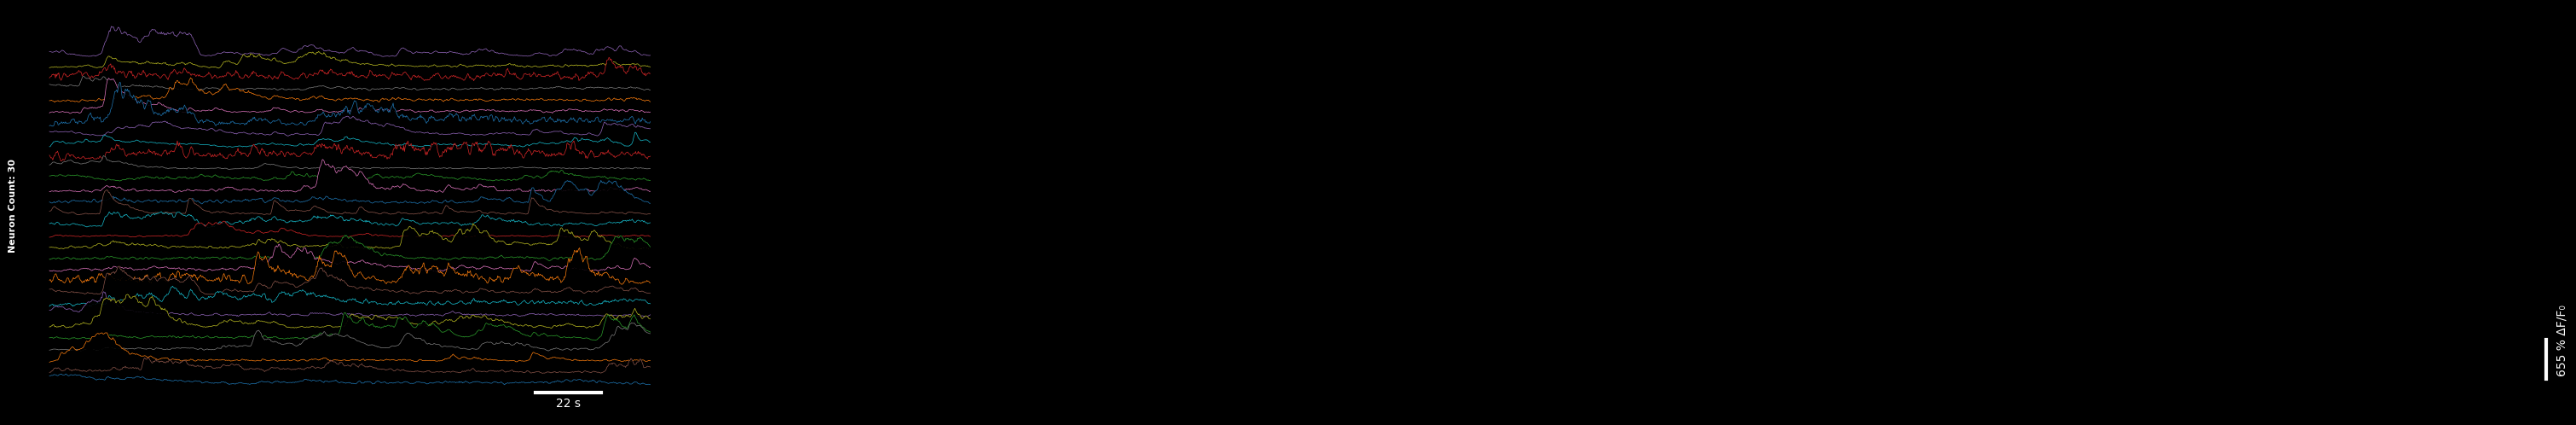

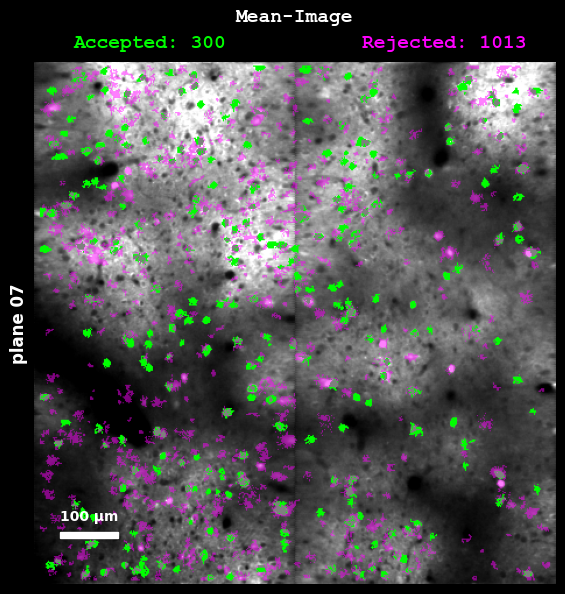

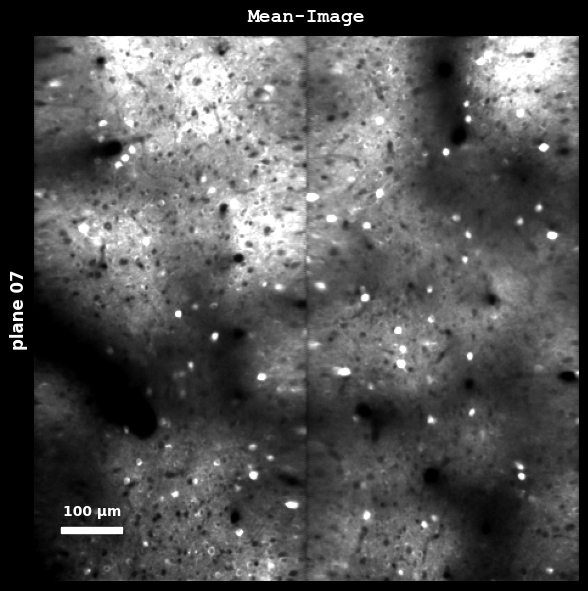

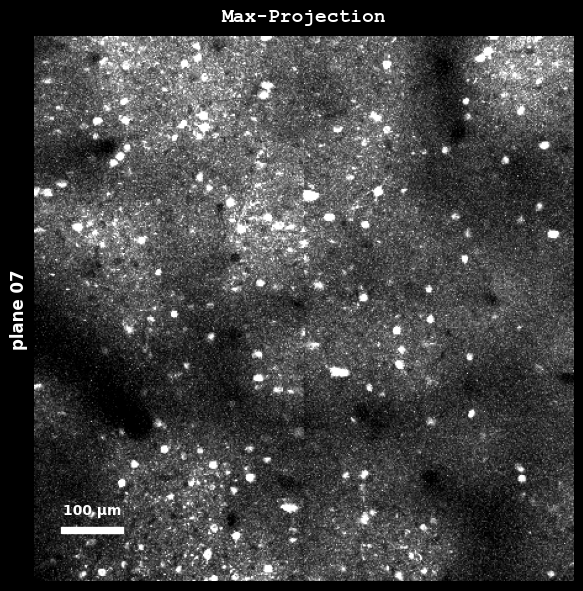

In [18]:
output_ops = lsp.run_plane(ops, demo_file, "D://demo_functional//results", save_folder=None, overwrite=True)

In [ ]:
import os
os.mkdir("D://demo_anatomical//results//figures")

In [19]:
f, fneu, spks = lsp.load_traces(output_ops)

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\demo_functional\\results\\plane_07\\plane0\\stats.npy'

In [54]:
stats[0]["skew"]

0.18128827

D:\demo_anatomical\assembled\plane_07.tif already has segmentation results. Skipping execution.
Generating missing plots for plane_07...
{'registration': 21.936908721923828, 'detection': 5.8625617027282715, 'extraction': 0.6053845882415771, 'classification': 0.019999265670776367, 'deconvolution': 0.015508651733398438, 'total_plane_runtime': 28.45737934112549}


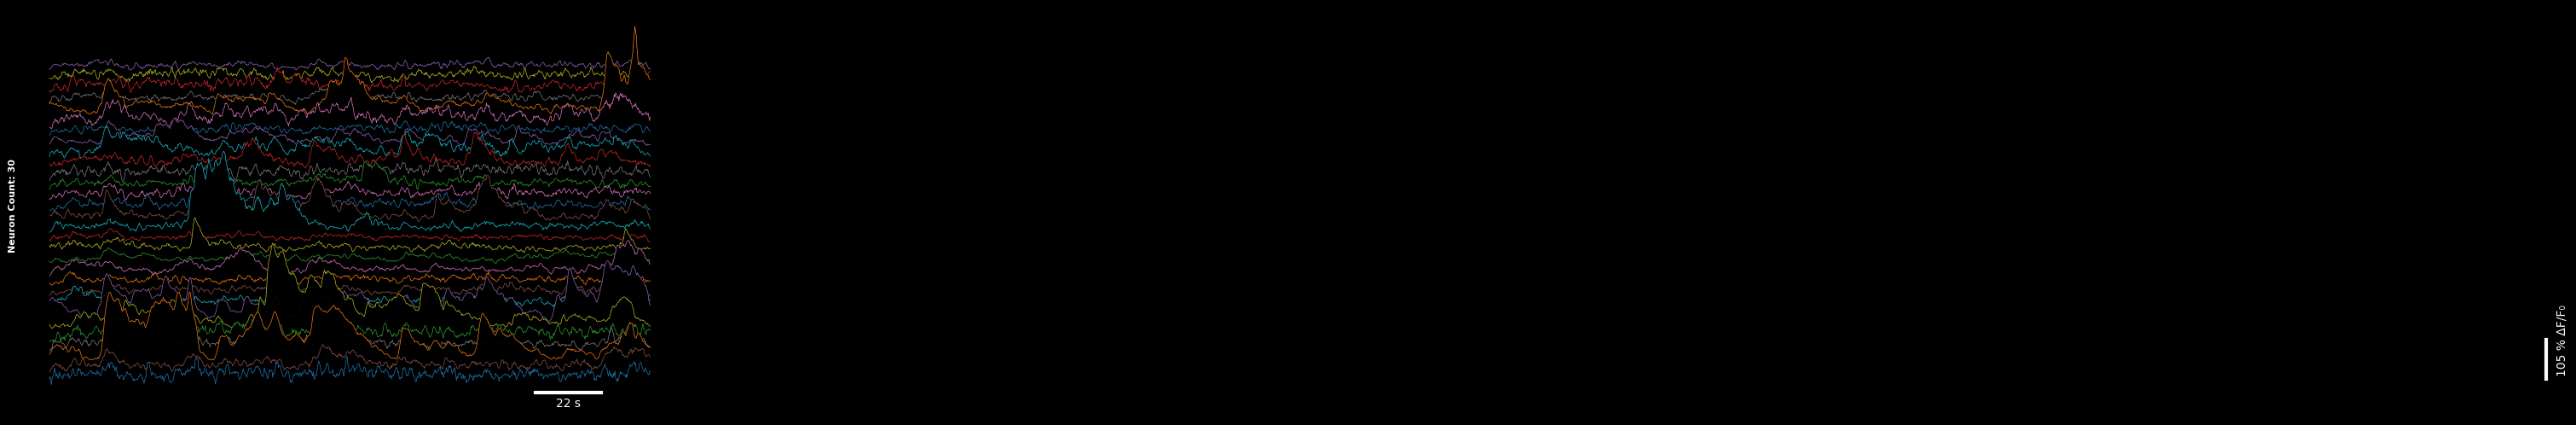

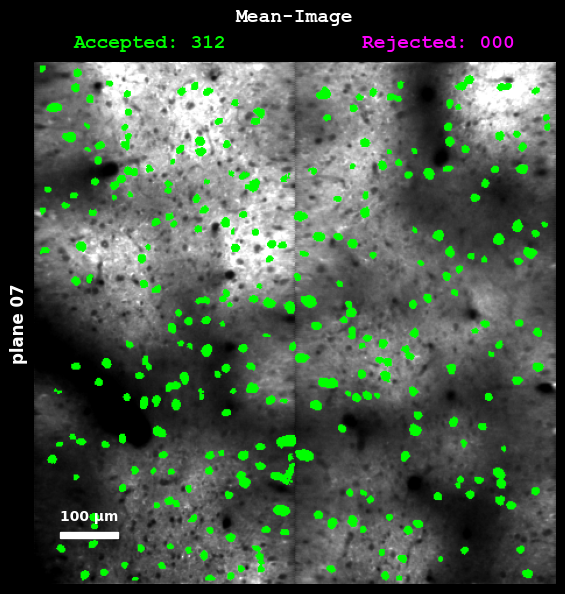

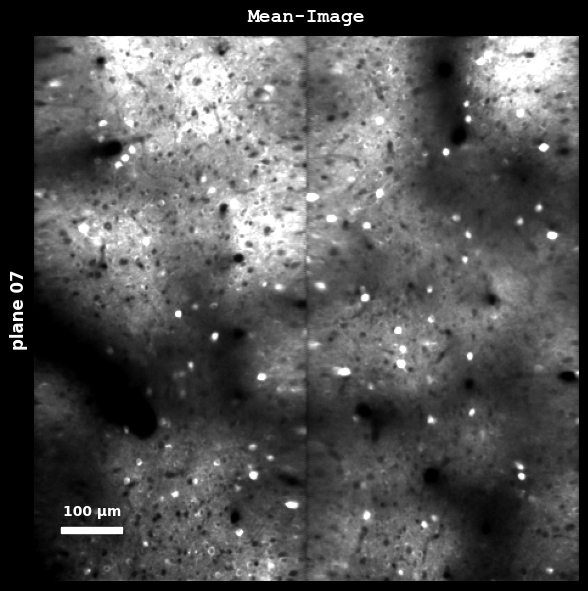

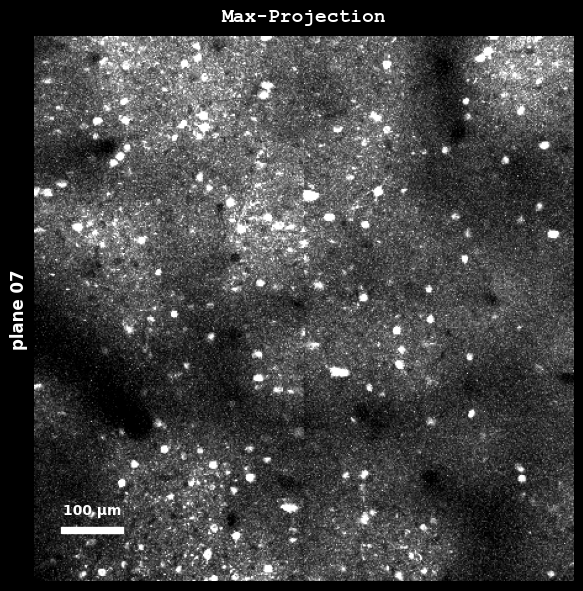

In [59]:
ops["tau"] = 0.15
ops["max_overlap"] = 1.0
ops["anatomical_only"] = 3
ops["cellprob_thresh"] = -6
ops["diameter"] = 7
ops["spatial_hp_cp"] = 1

output_ops = lsp.run_plane(ops, demo_file, "D://demo_anatomical//results", save_folder=None, overwrite=True)

In [ ]:
lsp.dff_

In [ ]:
gs = {spatial_hp_cp}
lsp.run_grid_search(ops, {}

In [99]:
import math
import matplotlib.offsetbox
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.offsetbox import VPacker, HPacker, DrawingArea
import numpy as np
from rastermap.utils import bin1d

from lbm_suite2p_python.utils import dff_percentile
from lbm_suite2p_python.utils import _resize_masks_fit_crop
from suite2p.detection.stats import ROI

def format_time(t):
    if t < 60:
        # make sure we dont show 0 seconds
        return f"{int(np.ceil(t))} s"
    elif t < 3600:
        return f"{int(round(t/60))} min"
    else:
        return f"{int(round(t/3600))} h"


def get_color_permutation(n):
    # choose a step from n//2+1 up to n-1 that is coprime with n
    for s in range(n//2 + 1, n):
        if math.gcd(s, n) == 1:
            return [(i * s) % n for i in range(n)]
    return list(range(n))


class AnchoredHScaleBar(matplotlib.offsetbox.AnchoredOffsetbox):
    """
    create an anchored horizontal scale bar.

    parameters
    ----------
    size : float, optional
        bar length in data units (fixed; default is 1).
    label : str, optional
        text label (default is "").
    loc : int, optional
        location code (default is 2).
    ax : axes, optional
        axes to attach the bar (default uses current axes).
    pad, borderpad, ppad, sep : float, optional
        spacing parameters.
    linekw : dict, optional
        line properties.
    """
    def __init__(self, size=1, label="", loc=2, ax=None, pad=0.4,
                 borderpad=0.5, ppad=0, sep=2, prop=None,
                 frameon=True, linekw=None, **kwargs):
        if linekw is None:
            linekw = {}
        if ax is None:
            ax = plt.gca()
        # trans = ax.get_xaxis_transform()
        trans = ax.transAxes

        size_bar = matplotlib.offsetbox.AuxTransformBox(trans)
        line = Line2D([0, size], [0, 0], **linekw)
        size_bar.add_artist(line)
        txt = matplotlib.offsetbox.TextArea(label)
        self.txt = txt
        self.vpac = VPacker(children=[size_bar, txt],
                            align="center", pad=ppad, sep=sep)
        super().__init__(loc, pad=pad, borderpad=borderpad,
                         child=self.vpac, prop=prop, frameon=frameon, **kwargs)

class AnchoredVScaleBar(matplotlib.offsetbox.AnchoredOffsetbox):
    """
    Create an anchored vertical scale bar.

    Parameters
    ----------
    height : float, optional
        Bar height in data units (default is 1).
    label : str, optional
        Text label (default is "").
    loc : int, optional
        Location code (default is 2).
    ax : axes, optional
        Axes to attach the bar (default uses current axes).
    pad, borderpad, ppad, sep : float, optional
        Spacing parameters.
    linekw : dict, optional
        Line properties.
    spacer_width : float, optional
        Width of spacer between bar and text.
    """
    def __init__(self, height=1, label="", loc=2, ax=None, pad=0.4,
                 borderpad=0.5, ppad=0, sep=2, prop=None,
                 frameon=True, linekw={}, spacer_width=6, **kwargs):
        if ax is None:
            ax = plt.gca()
        trans = ax.transAxes

        size_bar = matplotlib.offsetbox.AuxTransformBox(trans)
        line = Line2D([0, 0], [0, height], **linekw)
        size_bar.add_artist(line)

        txt = matplotlib.offsetbox.TextArea(label, textprops=dict(rotation=90, ha="left", va="bottom"))
        self.txt = txt

        spacer = DrawingArea(spacer_width, 0, 0, 0)
        self.hpac = HPacker(children=[size_bar, spacer, txt],
                            align="bottom", pad=ppad, sep=sep)
        super().__init__(loc, pad=pad, borderpad=borderpad,
                         child=self.hpac, prop=prop, frameon=frameon, **kwargs)

def plot_traces(
        f,
        save_path="",
        fps=17.0,
        num_neurons=20,
        window=220,
        title="",
        offset=None,
        lw=0.5,
        cmap='tab10',
        signal_units="dff"
):
    """
    Plot stacked fluorescence traces with automatic offset and scale bars.

    Parameters
    ----------
    f : ndarray
        2d array of fluorescence traces (n_neurons x n_timepoints).
    save_path : str, optional
        Path to save the output plot (default is "./stacked_traces.png").
    fps : float, optional
        Sampling rate in frames per second (default is 17.0).
    num_neurons : int, optional
        Number of neurons to display (default is 20).
    window : float, optional
        Time window (in seconds) to display (default is 120).
    title : str, optional
        Title of the figure (default is "").
    offset : float or None, optional
        Vertical offset between traces; if None, computed automatically.
    lw : float, optional
        Line width for data points.
    cmap : str, optional
        Matplotlib colormap string (default is 'tab10').
    signal_units : str, optional
        Units of fluorescence signal. Options: "DF/F0 %", "DF/F0", "raw signal" (default: "DF/F0 %").
    """
    if isinstance(f, dict):
        ops = f
        print("Loading dff (%) from ops-dict")
        res = load_planar_results(ops)
        f = res["F"]
        f = dff_percentile(f) * 100
        signal_units = "dff"

    _, n_timepoints = f.shape
    data_time = np.arange(n_timepoints) / fps
    current_frame = min(int(window * fps), n_timepoints - 1)
    displayed_neurons = num_neurons

    if offset is None:
        p10 = np.percentile(f[:displayed_neurons, :current_frame + 1], 10, axis=1)
        p90 = np.percentile(f[:displayed_neurons, :current_frame + 1], 90, axis=1)
        offset = np.median(p90 - p10) * 1.2

    cmap_inst = plt.get_cmap(cmap)
    colors = cmap_inst(np.linspace(0, 1, displayed_neurons))
    perm = get_color_permutation(displayed_neurons)
    colors = colors[perm]

    fig, ax = plt.subplots(figsize=(10, 6), facecolor='black')
    ax.set_facecolor('black')
    ax.tick_params(axis='x', which='both', labelbottom=False, length=0, colors='white')
    ax.tick_params(axis='y', which='both', labelleft=False, length=0, colors='white')
    for spine in ax.spines.values():
        spine.set_visible(False)

    for i in reversed(range(displayed_neurons)):
        trace = f[i, :current_frame + 1]
        baseline = np.percentile(trace, 8)
        shifted_trace = (trace - baseline) + i * offset

        ax.plot(data_time[:current_frame + 1], shifted_trace, color=colors[i], lw=lw, zorder=-i)

        if i < displayed_neurons - 1:
            prev_trace = f[i + 1, :current_frame + 1]
            prev_baseline = np.percentile(prev_trace, 8)
            prev_shifted = (prev_trace - prev_baseline) + (i + 1) * offset
            mask = shifted_trace > prev_shifted
            ax.fill_between(data_time[:current_frame + 1], shifted_trace, prev_shifted,
                            where=mask, color='black', zorder=-i - 1)

    all_shifted = [(f[i, :current_frame + 1] - np.percentile(f[i, :current_frame + 1], 10)) + i * offset
                   for i in range(displayed_neurons)]
    all_y = np.concatenate(all_shifted)
    y_min, y_max = np.min(all_y), np.max(all_y)
    x_range = window
    new_x_upper = window + 0.05 * x_range

    time_bar_length = 0.1 * window
    if time_bar_length < 60:
        time_label = f"{time_bar_length:.0f} s"
    elif time_bar_length < 3600:
        time_label = f"{time_bar_length / 60:.0f} min"
    else:
        time_label = f"{time_bar_length / 3600:.1f} hr"

    linekw = dict(color="white", linewidth=3)
    hsb = AnchoredHScaleBar(size=0.1, label=time_label,
                                loc=4, frameon=False, pad=0.6, sep=4, linekw=linekw, ax=ax)
    hsb.set_bbox_to_anchor((0.9, -0.05), transform=ax.transAxes)
    hsb.txt._text.set_color('white')
    
    ax.add_artist(hsb)

    dff_bar_height = 0.1 * (y_max - y_min)
    bottom_baseline = np.percentile(f[0, :current_frame + 1], 8)
    bottom_trace_min = np.min(f[0, :current_frame + 1] - bottom_baseline)
    rounded_dff = round(dff_bar_height / 5) * 5

    dff_label = f"{rounded_dff:.0f} % ΔF/F₀" if signal_units == "dff" else f"{rounded_dff:.0f} raw signal (a.u)"

    vsb = AnchoredVScaleBar(
        height=.1,
        label=dff_label,
        loc='lower right',
        frameon=False,
        pad=-.1,
        sep=4,
        linekw=linekw,
        ax=ax,
        spacer_width=0
    )
    vsb.set_bbox_to_anchor((1.00, 0.05), transform=ax.transAxes)
    # vsb.set_bbox_to_anchor(, transform=ax.transAxes)
    vsb.txt._text.set_color('white')
    ax.add_artist(vsb)

    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold", color="white")

    ax.set_ylabel(f"Neuron Count: {displayed_neurons}", fontsize=8, fontweight="bold", color="white", labelpad=2)

    if save_path:
        plt.savefig(save_path, dpi=200, facecolor=fig.get_facecolor())
        plt.close(fig)
    else:
        plt.show()

In [100]:
res = lsp.load_planar_results(r"D:\demo_anatomical\results\plane_07\plane0\ops.npy")
[x for x in res.keys()]

['F', 'Fneu', 'spks', 'stat', 'iscell', 'cellprob', 'z_plane']

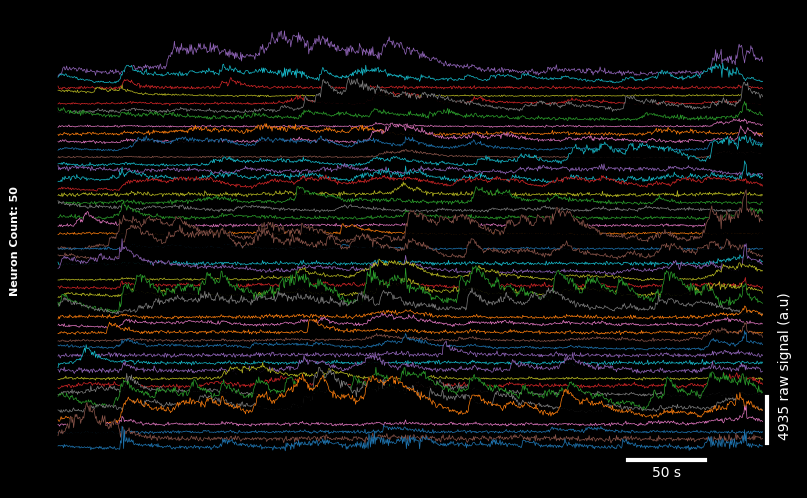

In [101]:
plot_traces(res["F"], signal_units='raw', num_neurons=50, window=500)